In [ ]:
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
from torch.utils.data import DataLoader 
import torchvision.datasets as datasets 
import torchvision.transforms as transforms
import pandas as pd
from torchvision import models
import wandb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip -q /content/drive/MyDrive/AAU/curated.zip -d /content

In [ ]:
wandb.init(project="ResNet")

wandb.config = {
    "batch_size": 128,
    "learning_rate": 0.1,
    "epochs": 20, 
    "momentum": 0.9,
    "dropout": 0.337,  
    "model": "ResNet with custom classifier",
    "criterion": "CrossEntropyLoss",
    "optimizer": "SGD",
}

In [3]:
transform = transforms.Compose([            
 transforms.Resize(256),                    
 transforms.CenterCrop(224),                
 transforms.ToTensor(),                     
 transforms.Normalize(                      
 mean=[0.485, 0.456, 0.406],                
 std=[0.229, 0.224, 0.225]                  
 )])

In [ ]:
train_data = datasets.ImageFolder('/content/curated/train',transform=transform)
test_data = datasets.ImageFolder('/content/curated/train',transform=transform)
valid_data=datasets.ImageFolder('/content/curated/train',transform=transform)

In [ ]:
batch_size = 128
train_loader = DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data,batch_size=batch_size,shuffle=True)
valid_loader= DataLoader(valid_data,batch_size=batch_size,shuffle=True)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
device

device(type='cuda')

In [8]:
classes = ('neutral','happiness','surprise','sadness','anger','disgust','fear','contempt')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


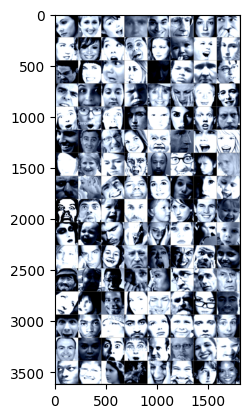

neutral happiness happiness neutral


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
#Function to show some random images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

#Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

#Show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

Pre-Trained Model:

In [12]:
model_resnet = torch.hub.load('pytorch/vision:v0.6.0', 'resnet18', pretrained=True)

Downloading: "https://github.com/pytorch/vision/zipball/v0.6.0" to C:\Users\Gabriel/.cache\torch\hub\v0.6.0.zip


c:\Users\Gabriel\source\repos\AIProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Gabriel\source\repos\AIProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Gabriel/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:25<00:00, 1.86MB/s]


In [13]:
from collections import OrderedDict
classifier=nn.Sequential(OrderedDict([('fc1', nn.Linear(9216, 512)),
                           ('relu', nn.ReLU()), 
                           ('dropout', nn.Dropout(p=0.337)),
                           ('fc2', nn.Linear(512, 7)),
                           ('output', nn.LogSoftmax(dim=1))
                             ]))
model_resnet.classifier = classifier

In [14]:
criteria = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet.parameters(), lr = 0.1, momentum = 0.9)


In [ ]:
#define training function
def train (model, loader, criterion, device):
    model.train()
    current_loss = 0
    current_correct = 0
    for train, y_train in iter(loader):
        train, y_train = train.to(device), y_train.to(device)
        optimizer.zero_grad()
        output = model(train) 
        _, preds = torch.max(output,1)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        current_loss += loss.item()*train.size(0)
        current_correct += torch.sum(preds == y_train.data)
    epoch_loss = current_loss / len(loader.dataset)
    epoch_acc = current_correct.double() / len(loader.dataset)

    wandb.log({"train_loss": epoch_loss, "train_accuracy": epoch_acc.item()})
        
    return epoch_loss, epoch_acc

In [ ]:
#define validation function
def validation (model, loader, criterion, device):
    model.eval()
    valid_loss = 0
    valid_correct = 0
    for valid, y_valid in iter(loader):
        valid, y_valid = valid.to(device), y_valid.to(device)
        output = model.forward(valid)
        valid_loss += criterion(output, y_valid).item()*valid.size(0)
        equal = (output.max(dim=1)[1] == y_valid.data)
        valid_correct += torch.sum(equal)#type(torch.FloatTensor)
    
    epoch_loss = valid_loss / len(loader.dataset)
    epoch_acc = valid_correct.double() / len(loader.dataset)

    wandb.log({"val_loss": epoch_loss, "val_accuracy": epoch_acc.item()})
    
    return epoch_loss, epoch_acc

In [ ]:
#Initialize training params  
#freeze gradient parameters in pretrained model
for param in model_resnet.parameters():
    param.require_grad = False
#train and validate
epochs = 20
epoch = 0
#send model to GPU
if device:
    model_resnet.to(device)
    
for e in range(epochs):
    epoch +=1
    print(epoch)
    with torch.set_grad_enabled(True):
        epoch_train_loss, epoch_train_acc = train(model_resnet,train_loader, criteria,device)
    print("Epoch: {} Train Loss : {:.4f}  Train Accuracy: {:.4f}".format(epoch,epoch_train_loss,epoch_train_acc))
    with torch.no_grad():
        epoch_val_loss, epoch_val_acc = validation(model_resnet, valid_loader, criteria,device)
    print("Epoch: {} Validation Loss : {:.4f}  Validation Accuracy {:.4f}".format(epoch,epoch_val_loss,epoch_val_acc))

1
Epoch: 1 Train Loss : 1.6905  Train Accuracy: 0.3483
Epoch: 1 Validation Loss : 1.6208  Validation Accuracy 0.2878


In [ ]:
torch.save(model_resnet.state_dict(),'/content/drive/MyDrive/AAU/ResNet')

NameError: name 'torch' is not defined